In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent
results_dir = root_dir / "data" / "olmo7b_results" / "v2"
sys.path.insert(0, str(root_dir))
from utils import load_json_data, save_dataframes

KEYWORD = "assumed"   # can otherwise be "assumed"
PREFIX = "combined"  # can be None

loaded_dfs = load_json_data(results_dir, 
                            file_name_keyword=KEYWORD, 
                            prefix=PREFIX)
print(f"Loaded the following {KEYWORD} dfs:")
for k in loaded_dfs.keys():
    print(k)

Loaded the following assumed dfs:
combined_metrics_olmo7b_assumed


In [2]:
# get first value of loaded_dfs
df = list(loaded_dfs.values())[0]
df.head()

,model_key,profile_id,temperature,occupation_category,attended_university,response_number,mean_entropy,mean_entropy_nucleus,gender,self_bleu,semantic_div,perplexity
0,base,1,0.2,officers in regular armed forces,no,1,0.166874,0.124336,male,0.440348,0.336028,8.630883
1,base,1,0.2,officers in regular armed forces,no,2,0.138992,0.097487,female,0.440348,0.336028,8.630883
2,base,1,0.2,officers in regular armed forces,no,3,0.150005,0.114144,male,0.440348,0.336028,8.630883
3,base,1,0.2,officers in regular armed forces,no,4,0.149667,0.108802,male,0.440348,0.336028,8.630883
4,base,1,0.2,officers in regular armed forces,no,5,0.157876,0.107500,male,0.440348,0.336028,8.630883


In [3]:
import pandas as pd
combined_df = None
if PREFIX == "combined":
    combined_df = list(loaded_dfs.values())[0]
    print("Combined df columns:", combined_df.columns)
    print("Combined df shape:", combined_df.shape)
elif len(loaded_dfs) > 1:
    # combine all dfs into one (vertically)
    all_dfs = list(loaded_dfs.values())
    combined_df = pd.concat(all_dfs).reset_index(drop=True)
    print("Combined df columns:", combined_df.columns)
    assert combined_df.shape[0] == sum(df.shape[0] for df in all_dfs), "Row count mismatch after concatenation"
    print("Combined df shape:", combined_df.shape)
    save_dataframes({f"combined_metrics_olmo7b_{KEYWORD}": combined_df}, results_dir)


Combined df columns: Index(['model_key', 'profile_id', 'temperature', 'occupation_category',
       'attended_university', 'response_number', 'mean_entropy',
       'mean_entropy_nucleus', 'gender', 'self_bleu', 'semantic_div',
       'perplexity'],
      dtype='object')
Combined df shape: (17600, 12)


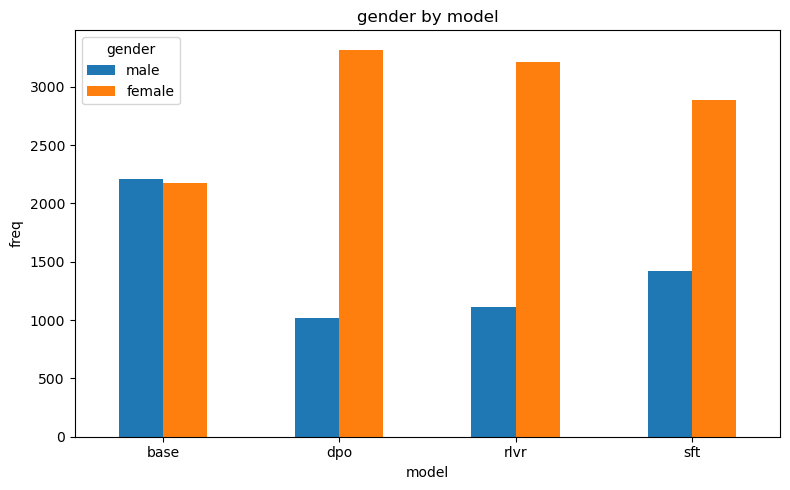

In [4]:
import matplotlib.pyplot as plt

gender_counts = (
    combined_df.groupby(["model_key", "gender"])
    .size()
    .unstack(fill_value=0)
)

gender_counts = gender_counts.reindex(columns=["male", "female"], fill_value=0)

ax = gender_counts.plot(kind="bar", figsize=(8, 5))
ax.set_title("gender by model")
ax.set_xlabel("model")
ax.set_ylabel("freq")
ax.legend(title="gender")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
occ_counts_gender = (
    combined_df.groupby(["model_key", "gender", "occupation_category"])
    .size()
    .unstack(fill_value=0)
)

In [6]:
combined_df["gender"].unique()

array(['male', 'female', 'unspecified'], dtype=object)

C:\Users\manth\AppData\Local\Temp\ipykernel_39748\3100366243.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


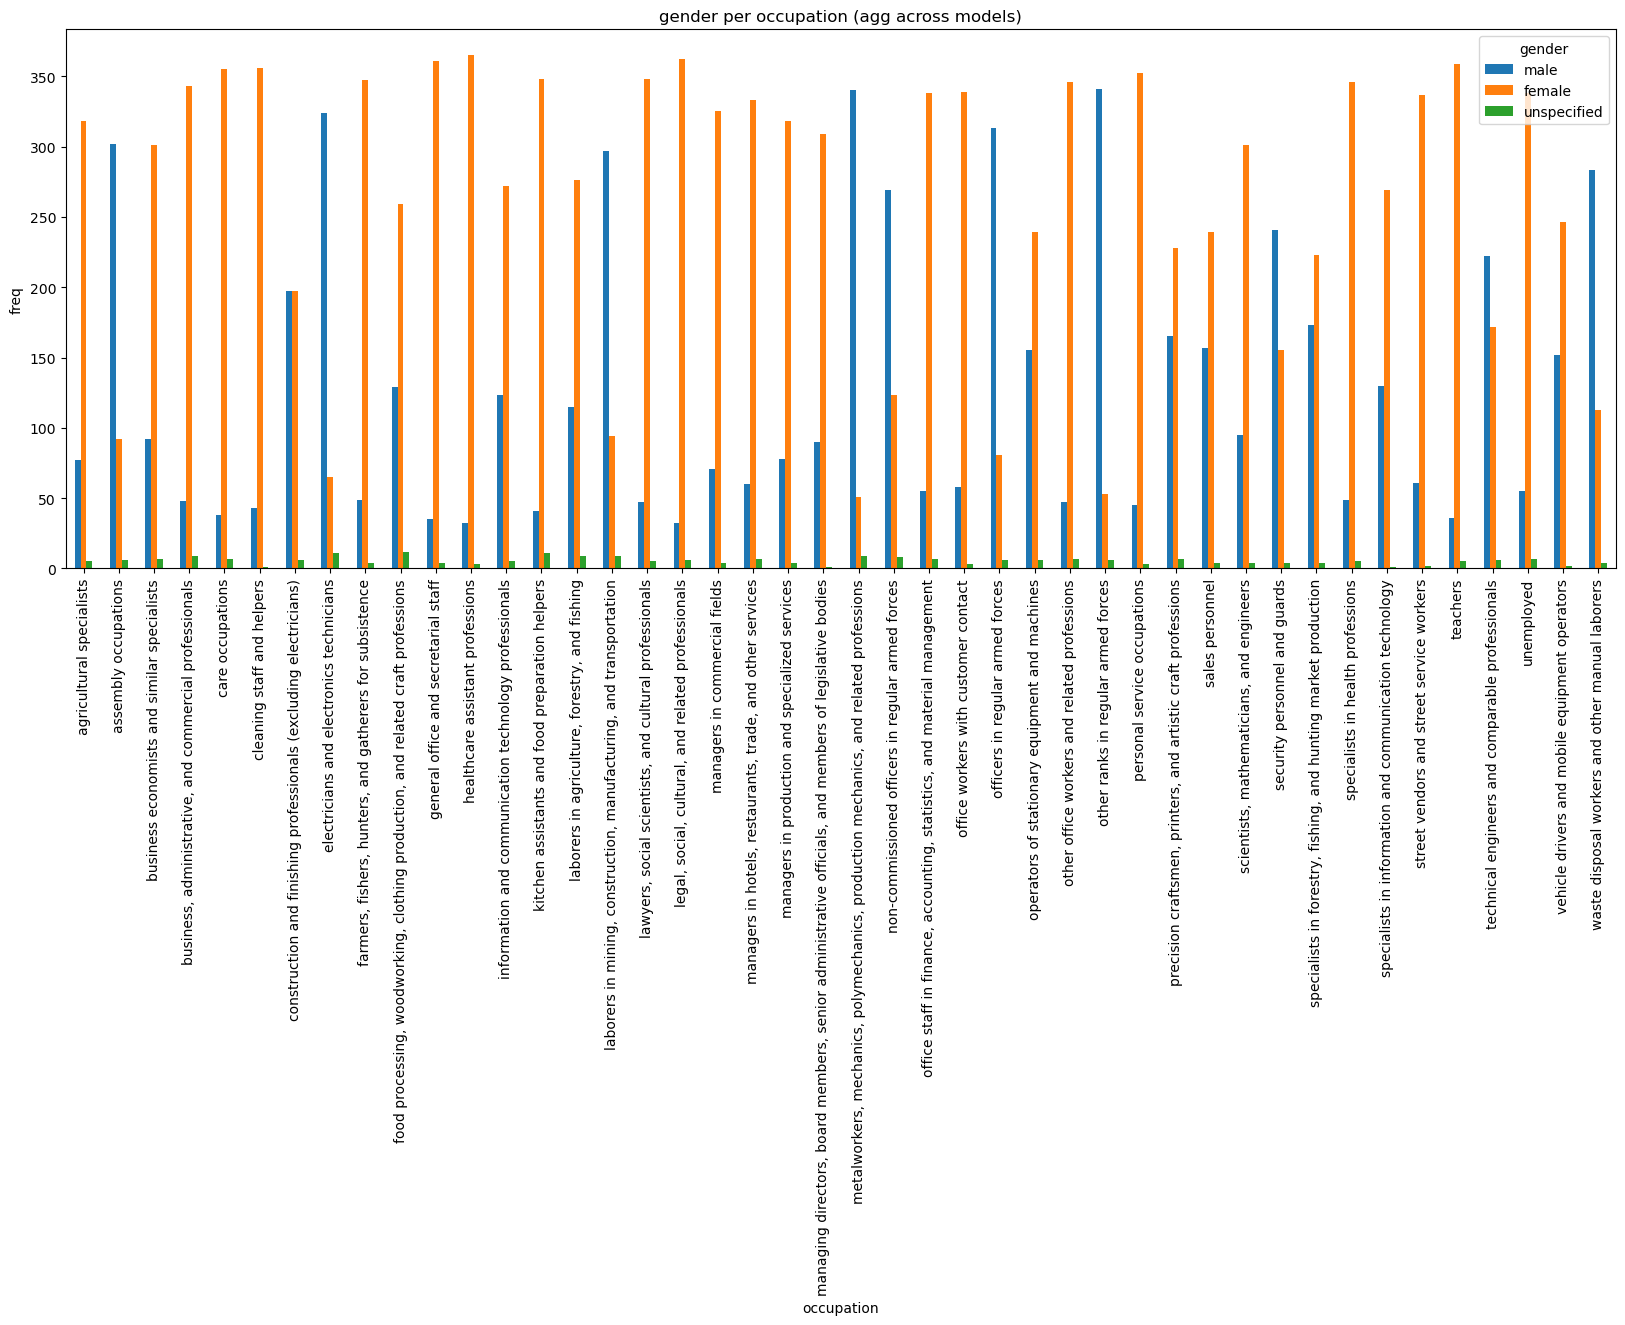

In [7]:
gender_counts_per_occupation = occ_counts_gender.groupby(level="gender").sum().T
gender_counts_per_occupation = gender_counts_per_occupation.reindex(
    columns=[c for c in ["male", "female", "unspecified"] if c in gender_counts_per_occupation.columns]
)

ax = gender_counts_per_occupation.plot(kind="bar", figsize=(20, 7))
ax.set_title("gender per occupation (agg across models)")
ax.set_xlabel("occupation")
ax.set_ylabel("freq")
ax.legend(title="gender")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

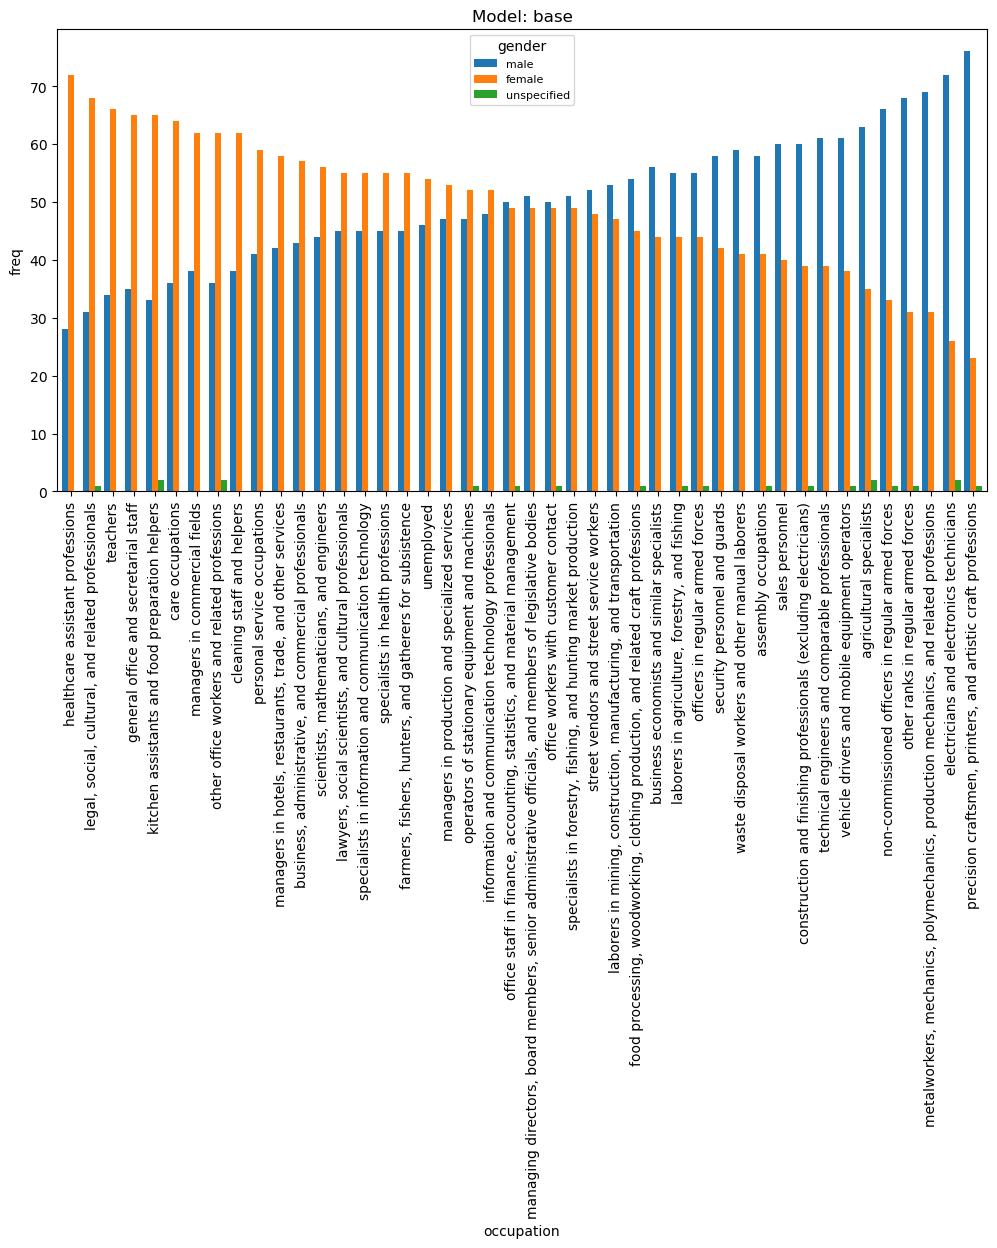

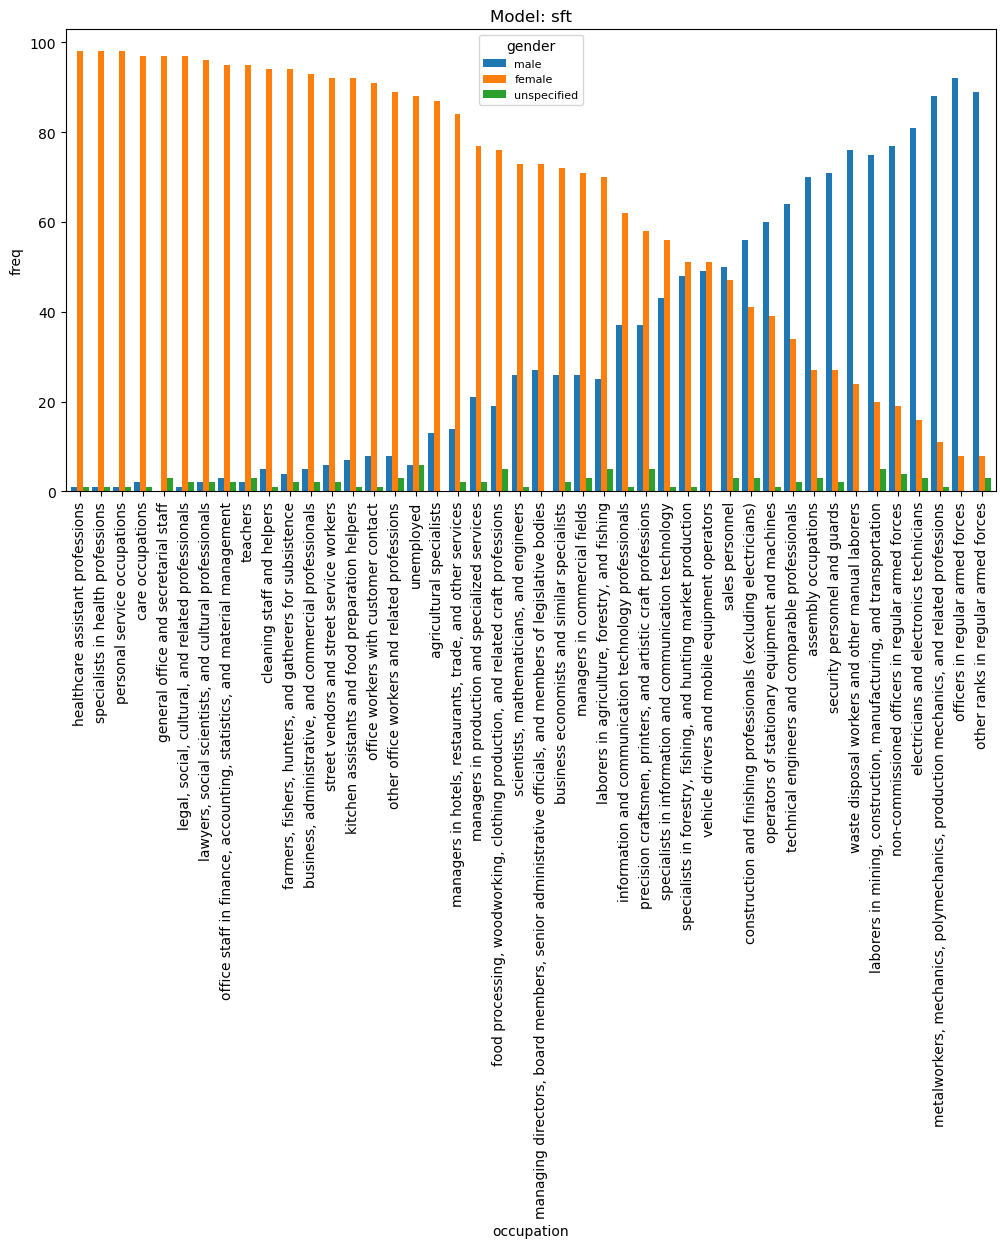

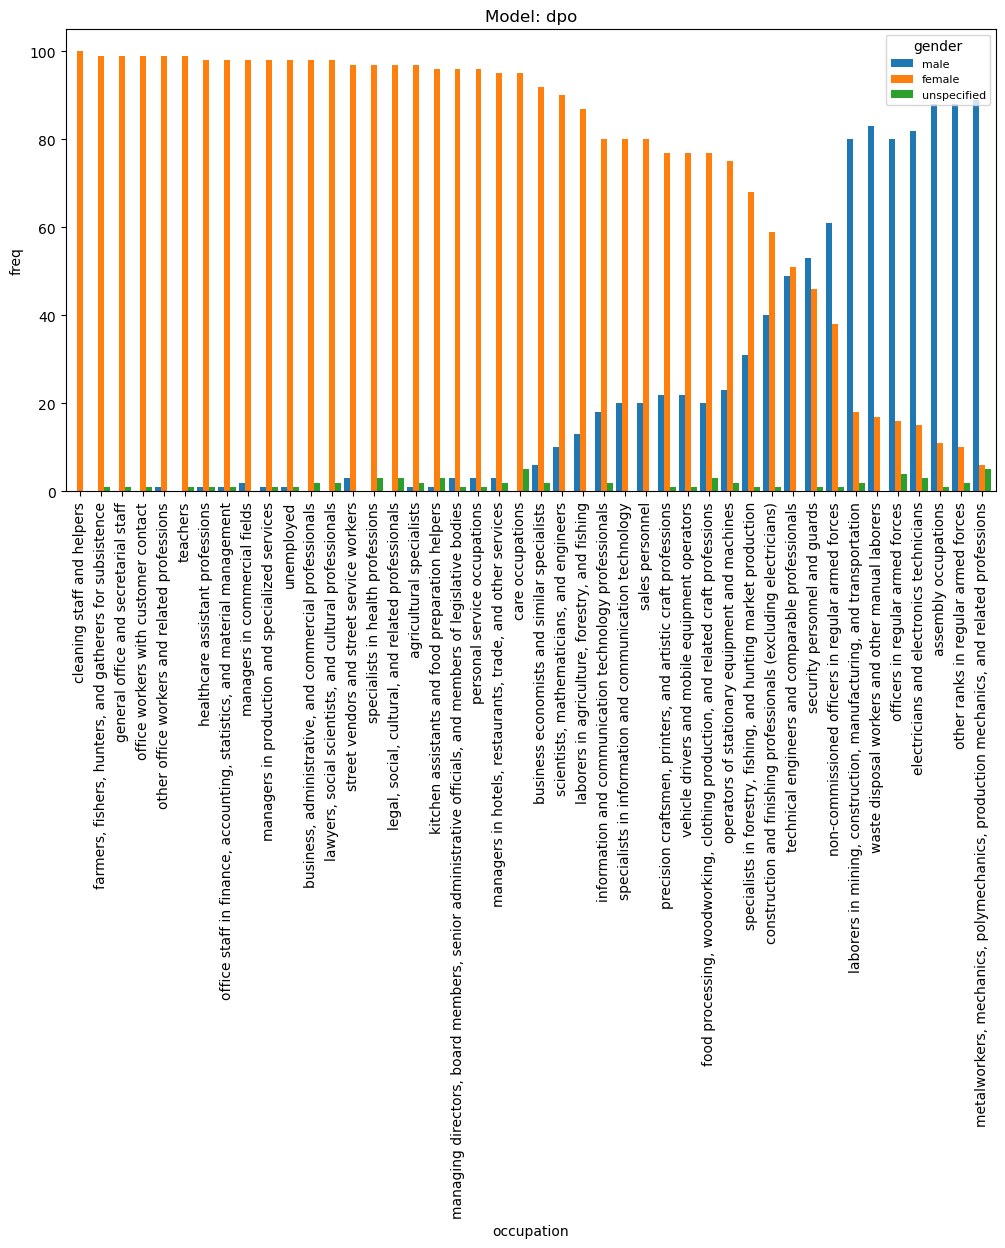

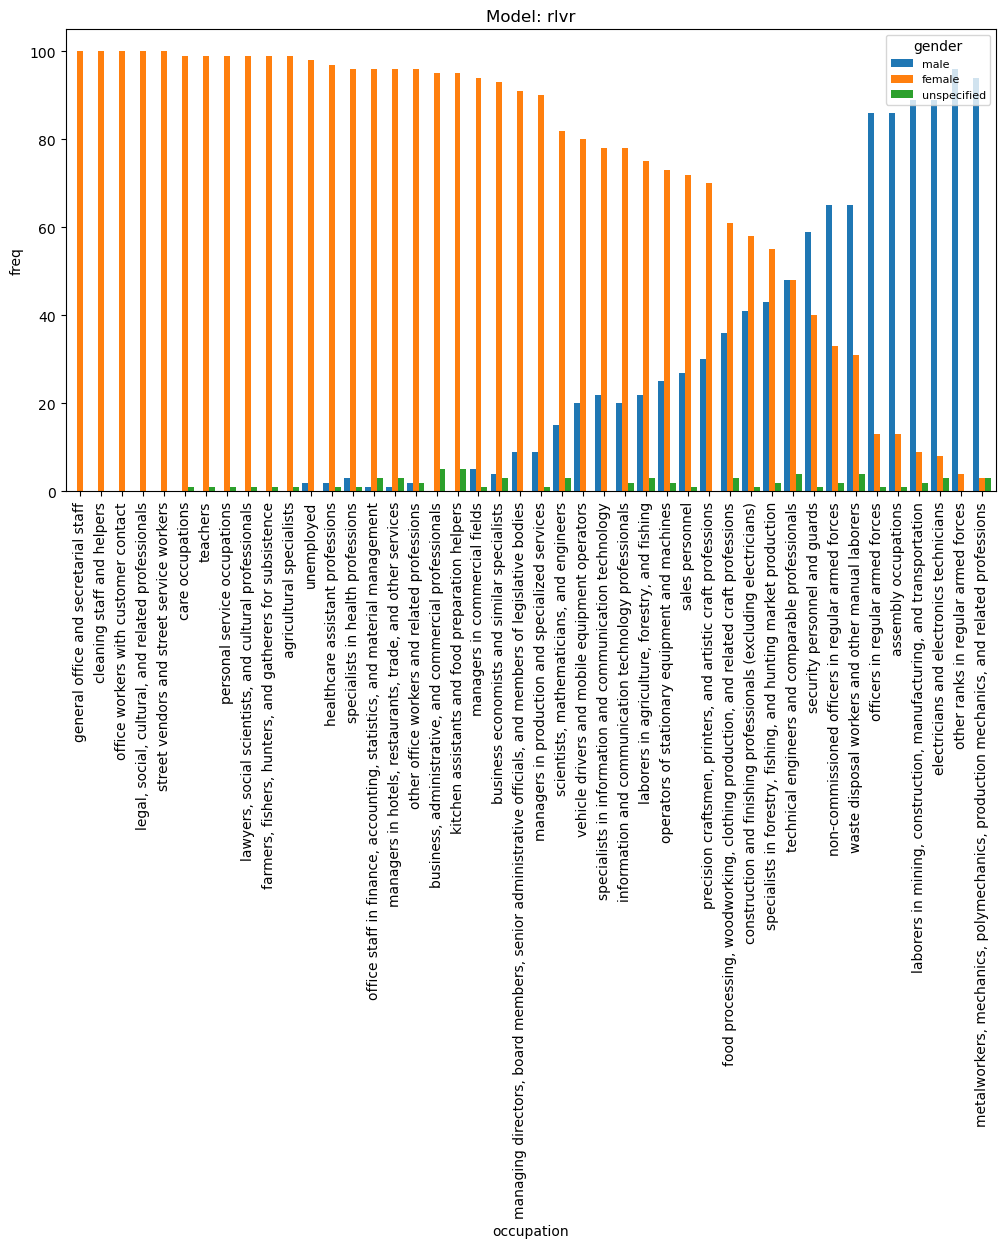

In [9]:
model_keys = [m for m in ["base", "sft", "dpo", "rlvr"] if m in combined_df["model_key"].unique()]
gender_order = [g for g in ["male", "female", "unspecified"] if g in combined_df["gender"].unique()]

for model in model_keys:
    # plot gender counts per occupation for each model
    fig = plt.figure(figsize=(12, 6))
    plot_df = occ_counts_gender.loc[model].reindex(gender_order, fill_value=0).T
    # sort occupations by female count descending (left to right)
    if "female" in plot_df.columns:
        plot_df = plot_df.sort_values("female", ascending=False)
    plot_df.plot(kind="bar", ax=plt.gca(), width=0.85)
    plt.title(f"Model: {model}")
    plt.xlabel("occupation")
    plt.ylabel("freq")
    plt.xticks(rotation=90)
    plt.legend(title="gender", fontsize=8)
    plt.show()

In [10]:
# build a dataframe with one column per model listing occupations sorted by female count (desc)
models = model_keys  # reuse existing variable

ordered = {}
for m in models:
    # get female counts for this model (fallback to zeros if missing)
    try:
        male_counts = occ_counts_gender.loc[m].loc["male"]
    except Exception:
        male_counts = pd.Series(0, index=occ_counts_gender.columns)
    ordered[m] = male_counts.sort_values(ascending=False).index.tolist() # This way I get the "most male-dominated"  to "least male-dominated"

ordered_df = pd.DataFrame(ordered)
ordered_df.index.name = "rank"  # rank 0 = highest female count
ordered_df.head()  # show top rows

,base,sft,dpo,rlvr
rank,,,,
0,"precision craftsmen, printers, and artistic cr...",officers in regular armed forces,"metalworkers, mechanics, polymechanics, produc...",other ranks in regular armed forces
1,electricians and electronics technicians,other ranks in regular armed forces,assembly occupations,"metalworkers, mechanics, polymechanics, produc..."
2,"metalworkers, mechanics, polymechanics, produc...","metalworkers, mechanics, polymechanics, produc...",other ranks in regular armed forces,electricians and electronics technicians
3,other ranks in regular armed forces,electricians and electronics technicians,waste disposal workers and other manual laborers,"laborers in mining, construction, manufacturin..."
4,non-commissioned officers in regular armed forces,non-commissioned officers in regular armed forces,electricians and electronics technicians,officers in regular armed forces


In [12]:
import json
occ_dir = root_dir / "data" / "occupations"

for col in ordered_df.columns:
    occ_list = ordered_df[col].tolist()
    occ_dict = [{"rank": (i + 1), "occupation": occ} for i, occ in enumerate(occ_list)]
    with open(occ_dir / f"occupations_{col}.json", "w") as f:
        json.dump(occ_dict, f, indent=2)